#### ツール呼び出しエージェントの構築

LangGraphとTavilyを使用して、ツールの呼び出しを動的に判断するエージェントを作成

◆準備

In [1]:
# 必要なモジュールをインポート
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# 環境変数の読み込み
load_dotenv("../.env")
os.environ['OPENAI_API_KEY'] = os.environ['API_KEY']

# モデル名
MODEL_NAME = "gpt-4o-mini"

◆　検索ツールの定義

LangChainにはTavily用のツール TavilySearchResults が用意されている。これを使ってWeb検索ツールを定義。

In [2]:
# 検索ツールの定義
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]


In [4]:
# 検索ツールの動作確認
tool.invoke("Langgraphのノードとは？")

[{'url': 'https://qiita.com/ktdatascience/items/5642175f0377f201bab3',
  'content': 'LangGraphは、このような多段階の思考プロセスを「グラフ」として表現し、AIに実行させることができます。\n\n## LangGraphの仕組み\n\n### 基本構造の理解\n\nLangGraphは以下の3つの要素から構成されています：\n\nノード（Node）: 具体的な処理を行う単位\n\n 情報検索ノード\n 計算ノード\n 推論ノード\n 回答生成ノードなど\n\nエッジ（Edge）: ノード間の接続と制御フロー\n\n どのノードからどのノードへ進むかを定義\n 条件に応じた分岐も可能\n\n状態（State）: 各ノード間で共有される情報\n\n 処理の途中結果を保存\n 次のノードが参照できる\n\n### 全体の流れ\n\n## 実際の動作例で理解する\n\n具体的な例として、「東京の明日の天気を教えて、雨なら傘の準備をアドバイスして」という質問に対するLangGraphの処理を見てみましょう。\n\n### 処理の流れ\n\n## 状態管理の重要性\n\nLangGraphの核となるのが状態管理です。各ノードの処理結果は中央の状態オブジェクトに保存され、他のノードがこの情報を参照できます。\n\n### 状態に保存される情報の例 [...] 再利用性: 一度作成したノードは他のエージェントでも再利用可能\n\n## 実際の活用例\n\nカスタマーサポートエージェント:\n\n1. 問い合わせ内容の分類\n2. FAQ検索\n3. 過去の対応履歴確認\n4. 専門部署への転送判定\n5. 回答生成\n\nデータ分析エージェント:\n\n1. データソースの特定\n2. データ取得・前処理\n3. 分析手法の選択\n4. 分析実行\n5. 結果の可視化\n6. レポート生成\n\n## まとめ\n\nLangGraphは、従来の一問一答型のAIを超えて、人間のような複雑な思考プロセスを持つAIエージェントを構築するための強力なツールです。グラフ構造による柔軟な制御フローと状態管理により、様々な分野での高度なAIアプリケーション開発が可能になります。\n\n0\n\nGo to

◆　ステートグラフの作成とチャットボットノードの追加

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

# Stateクラスの定義
class State(TypedDict):
    messages: Annotated[list, add_messages]

# グラフのインスタンスを作成
graph_builder = StateGraph(State)

# 言語モデルの定義
llm = ChatOpenAI(model_name=MODEL_NAME)

# 変更点：ツール定義の紐づけ
llm_with_tools = llm.bind_tools(tools)

# チャットボットノードの作成
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# グラフにチャットボットノードを追加
graph_builder.add_node("chatbot", chatbot)

◆ツールノードの追加
グラフにツールノードを追加して、記憶を持つ実行可能なステートグラフを作成します。



In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ツールノードの作成
tool_node = ToolNode(tools)

# グラフにツールノードを追加
graph_builder.add_node("tools", tool_node)

# 条件付エッジの作成  
graph_builder.add_conditional_edges(
    "chatbot",  #第一引数：遷移元（チャットボット　
    tools_condition, # ツール呼出と判断したらツールノードを呼ぶ
)

# ツールが呼び出されるたびに、チャットボットに戻って次のステップを決定
# ツールからチャットボットへの戻りエッジを作成
graph_builder.add_edge("tools", "chatbot")

# 開始ノードの指定
graph_builder.set_entry_point("chatbot")

# 記憶を持つ実行可能なステートグラフの作成
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

作成したステートグラフを可視化

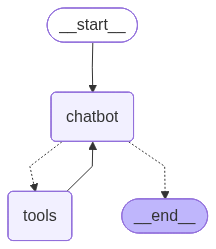

In [7]:
# グラフの可視化
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

◆動作確認

In [8]:
# グラフの実行と結果の表示
def stream_graph_updates(user_input: str):
    events = graph.stream(
        {"messages": [("user", user_input)]},
        {"configurable": {"thread_id": "1"}},
        stream_mode="values")
    # 結果をストリーミングで得る
    for event in events:
        print(event["messages"][-1].content, flush=True)

# チャットボットのループ
while True:
    user_input = input("質問:")
    if user_input.strip()=="":
        print("ありがとうございました!")
        break
    stream_graph_updates(user_input)

こんにちは！
こんにちは！何かお手伝いできることはありますか？
1＋２は？
1 + 2 は 3 です。何か他に知りたいことはありますか？
1メートル以上の犬は？

[{"url": "https://www.breeder-navi.jp/column/knowledge/basic/super-large-dog/", "content": "グレート・デーンは、体長と体高がほとんど同じという超大型犬でスマートさと優雅さから強さと美しさのシンボルとして、「犬の中の太陽神アポロン」と評されています。  \n 2004年には、ギブソンというグレートデーンが、体高107㎝でギネスブックに掲載されました。\n\n### 超大型犬④：アイリッシュウルフハウンド\n\n|  |  |\n --- |\n| 正式犬種名 | アイリッシュ・ウルフハウンド |\n| 原産国 | アイルランド |\n| 平均体高 | オス79～86cm  メス71cm～ |\n| 平均体重 | オス54.5kg～  メス40.5kg～ |\n\n全犬種中最も高い体高を持つといわれる、アイルランド原産の超大型犬で、体高が1m以上、2本足で立つと2mを超える個体も。オオカミより足が速く、単独でオオカミを倒せる犬種といわれています。  \n 外見的には、ゴワゴワな被毛と可愛らしい垂れ耳が特徴です。\n\n### 超大型犬⑤：ドーベルマン\n\n|  |  |\n --- |\n| 正式犬種名 | ドーベルマン |\n| 原産国 | ドイツ |\n| 平均体高 | オス68～72cm  メス63～68cm |\n| 平均体重 | オス40～45kg  メス32～35kg |\n\n超大型犬の中でも最も有名な犬種の1種で、その賢さと忠誠心の強さから、警察犬や軍用犬といった使役犬として活躍しています。  \n 真っ黒で艶やかな毛並みと引き締まった体躯の、とても精悍な印象の犬種です。\n\n### 超大型犬⑥：ニューファンドランド\n\n|  |  |\n --- |\n| 正式犬種名 | ニューファンドランド |\n| 原産国 | カナダ |\n| 平均体高 | オス71cm  メス66cm |\n| 平均体重 | オス68kg  メス54kg | [...] ### 超大型犬①：バーニーズマウンテンドッグ\n